# Sentinel-2 image and rasters processing notebook

**Description**

This notebook is used for processing Sentinel-2 images including calculating indices and stack all rasters together. The stacked image is used as an input of deep learning model in later step.

Main steps of Sentinel-2 image and rasters processing:
1. Import data
2. Calculate indices (NDVI, NDWI, and NDBI)
3. Stack Sentinel-2 image, PUGS binary mask, and PUGS SDT raster together

*PUGS = public urban green space, SDT = signed-distance transform*

**Input files**
3 raster files
- sentinel2_openeo_med_4months_dresden.geotiff
- public_green_spaces_dresden.geotiff
- sdt_public_green_spaces_dresden.geotiff

**Output files**

1 geotiff file
- stacked_sentinel2_dresden.geotiff

**Requirements/Dependencies**

This notebook requires user to run *1_data_acquisition_satellite_image.ipynb*, *1_data_acquisition_osm.ipynb*, and *2_data_processing_osm.ipynb* first.

# Import libraries

In [1]:
import os
import sys

# Add the root directory to Python path so that we can import the modules
root_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(root_dir)

In [2]:
import rioxarray
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import geopandas as gpd
from osgeo import gdal
from pugs_detection.raster import (
    contrast_stretch,
    normalize_sdt_minmax,
    contrast_stretch_dn,
)

# Import Sentinel-2 image

In [3]:
file_path = "../data/raw/sentinel-2/cm_sentinel2_l1c_openeo_med_4months_dresden.geotiff"
# file_path = '../data/raw/sentinel-2/sentinel2_openeo_med_4months_dresden.geotiff'
data = rioxarray.open_rasterio(file_path, masked=True)

Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as 

## Explore value

In [4]:
import rasterio
from rasterio.warp import Resampling

# Open with explicit resampling method
data_bilinear = rioxarray.open_rasterio(
    file_path,
    masked=True,
    resampling=Resampling.cubic,  # Explicitly set resampling
)

Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as 

In [5]:
data.sizes["band"]

13

In [6]:
# Print resolution for each band
for i in range(data.sizes["band"]):
    band = data.sel(band=i + 1)
    # Get resolution from transform
    if hasattr(band, "rio"):
        res = band.rio.resolution()
        print(f"Band {i + 1} resolution: {res} meters")

Band 1 resolution: (10.0, -10.0) meters
Band 2 resolution: (10.0, -10.0) meters
Band 3 resolution: (10.0, -10.0) meters
Band 4 resolution: (10.0, -10.0) meters
Band 5 resolution: (10.0, -10.0) meters
Band 6 resolution: (10.0, -10.0) meters
Band 7 resolution: (10.0, -10.0) meters
Band 8 resolution: (10.0, -10.0) meters
Band 9 resolution: (10.0, -10.0) meters
Band 10 resolution: (10.0, -10.0) meters
Band 11 resolution: (10.0, -10.0) meters
Band 12 resolution: (10.0, -10.0) meters
Band 13 resolution: (10.0, -10.0) meters


In [7]:
for i in range(data.sizes["band"]):
    band = data.sel(band=i + 1)
    print(band.values)
    print()

[[1067. 1067. 1067. ... 1273. 1273. 1273.]
 [1069. 1069. 1069. ... 1316. 1316. 1316.]
 [1069. 1069. 1069. ... 1316. 1316. 1316.]
 ...
 [1056. 1056. 1056. ... 1195. 1195. 1195.]
 [1062. 1062. 1062. ... 1192. 1192. 1192.]
 [1062. 1062. 1062. ... 1192. 1192. 1192.]]

[[ 765.  779.  774. ...  984. 1017. 1035.]
 [ 786.  793.  797. ... 1041. 1019. 1023.]
 [ 770.  784.  788. ... 1065. 1062. 1051.]
 ...
 [ 758.  755.  759. ...  980. 1016. 1047.]
 [ 760.  757.  760. ...  897. 1014. 1050.]
 [ 761.  776.  763. ...  873.  980. 1026.]]

[[ 631.  639.  649. ...  903.  942.  989.]
 [ 631.  654.  683. ...  998.  956.  966.]
 [ 627.  636.  654. ... 1053. 1039. 1020.]
 ...
 [ 632.  604.  590. ...  951.  966.  982.]
 [ 620.  614.  610. ...  802.  936.  975.]
 [ 638.  659.  632. ...  758.  912.  966.]]

[[ 370.  385.  381. ...  771.  843.  887.]
 [ 376.  396.  410. ...  942.  894.  896.]
 [ 364.  384.  389. ... 1033. 1007.  981.]
 ...
 [ 377.  360.  362. ...  804.  956. 1070.]
 [ 375.  355.  368. ...  640

In [8]:
data.isel(band=1).min()

<xarray.DataArray ()> Size: 4B
array(581., dtype=float32)
Coordinates:
    band         int64 8B 2
    spatial_ref  int64 8B 0

In [9]:
import numpy as np

data_new = np.where(data < 0, 0, data)

In [10]:
data_new_norm = data_new / 10000

In [11]:
data_new_norm_xarray = data.copy()
data_new_norm_xarray.data = data_new_norm

In [12]:
print(data_new_norm_xarray.min())
print(data_new_norm_xarray.max())

<xarray.DataArray ()> Size: 4B
array(0., dtype=float32)
Coordinates:
    spatial_ref  int64 8B 0
<xarray.DataArray ()> Size: 4B
array(2.3206, dtype=float32)
Coordinates:
    spatial_ref  int64 8B 0


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..2.2591].


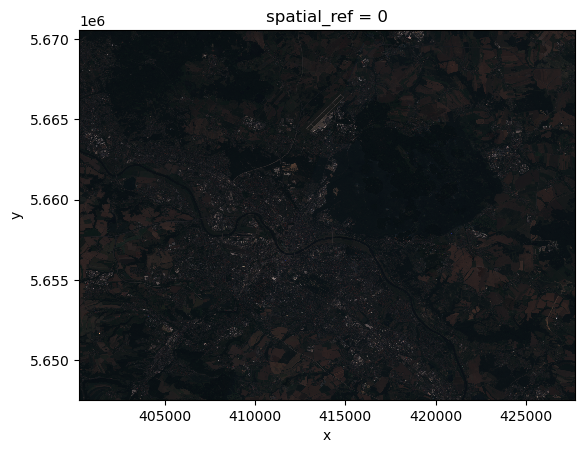

In [13]:
data_new_norm_xarray.sel(band=[4, 3, 2]).plot.imshow()

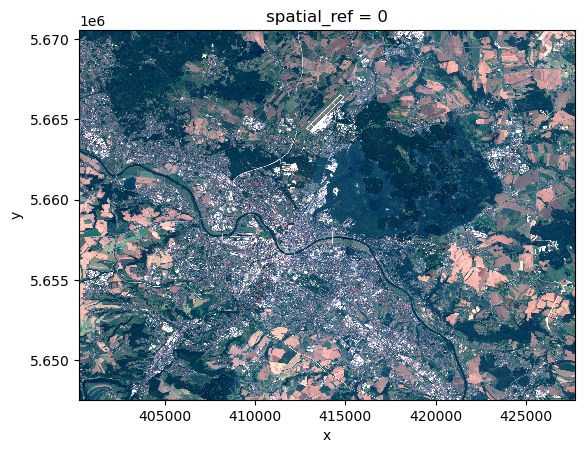

In [14]:
data_new_norm_xarray.sel(band=[4, 3, 2]).plot.imshow(robust=True)

## Normalize Sentinel-2 image values to [0,1] range
Min and max normalization give the worst result according to https://medium.com/sentinel-hub/how-to-normalize-satellite-images-for-deep-learning-d5b668c885af

In [15]:
# processed_sat_img = contrast_stretch(data)
processed_sat_img = contrast_stretch_dn(data)

In [16]:
print(processed_sat_img.min().values)
print(processed_sat_img.max().values)

0.0
1.0


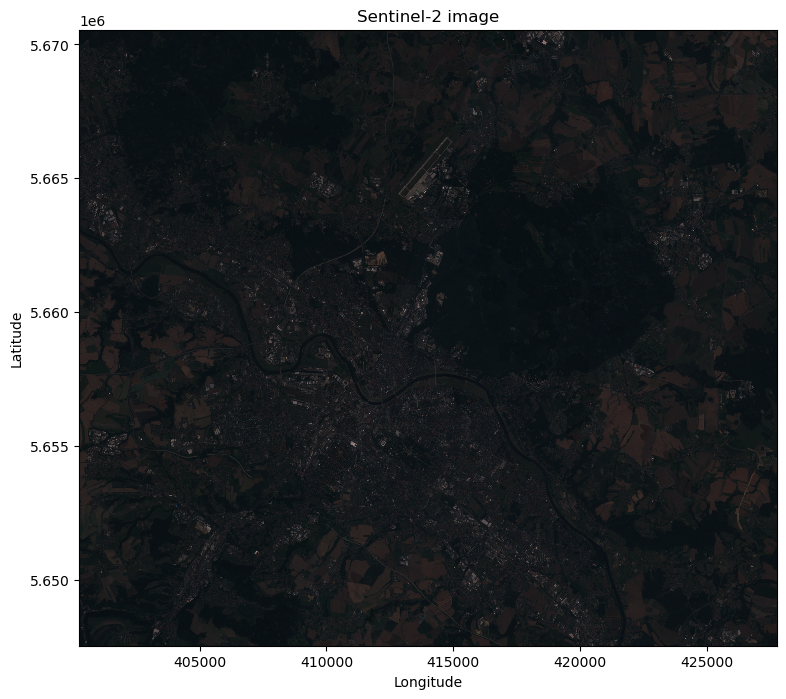

In [17]:
# Plot the raster data
plt.figure(figsize=(9, 8))
processed_sat_img.sel(band=[4, 3, 2]).plot.imshow()
plt.title("Sentinel-2 image")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

# Import binary mask

In [18]:
file_path = "../data/processed/osm/public_green_spaces_dresden.geotiff"
binary_mask_pugs = rioxarray.open_rasterio(file_path)

In [19]:
binary_mask_pugs = binary_mask_pugs.assign_coords(band=[14])
binary_mask_pugs

<xarray.DataArray (band: 1, y: 2301, x: 2747)> Size: 6MB
[6320847 values with dtype=uint8]
Coordinates:
  * x            (x) float64 22kB 4.003e+05 4.003e+05 ... 4.277e+05 4.277e+05
  * y            (y) float64 18kB 5.671e+06 5.671e+06 ... 5.648e+06 5.648e+06
    spatial_ref  int64 8B 0
  * band         (band) int64 8B 14
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

# Import SDT raster

In [20]:
file_path = "../data/processed/osm/sdt_public_green_spaces_dresden.geotiff"
sdt_pugs = rioxarray.open_rasterio(file_path)

In [21]:
sdt_pugs = sdt_pugs.assign_coords(band=[15])
sdt_pugs

<xarray.DataArray (band: 1, y: 2301, x: 2747)> Size: 51MB
[6320847 values with dtype=float64]
Coordinates:
  * x            (x) float64 22kB 4.003e+05 4.003e+05 ... 4.277e+05 4.277e+05
  * y            (y) float64 18kB 5.671e+06 5.671e+06 ... 5.648e+06 5.648e+06
    spatial_ref  int64 8B 0
  * band         (band) int64 8B 15
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

In [22]:
def min_max_normalize(data):
    """Scale data to 0-1 range using min-max normalization"""
    min_val = data.min().values
    max_val = data.max().values
    return (data - min_val) / (max_val - min_val)

## Normalize SDT values to [-1,1] range

In [23]:
# Check the range of your SDT values
print("SDT min:", sdt_pugs.min().values, ", SDT max:", sdt_pugs.max().values)

normalized_sdt_pugs = sdt_pugs.copy()
# Apply normalization
# normalized_sdt_pugs.values = normalize_sdt_minmax(sdt_pugs.values)
normalized_sdt_pugs.values = min_max_normalize(sdt_pugs)

SDT min: -252.20031720836514 , SDT max: 91.76055797563569


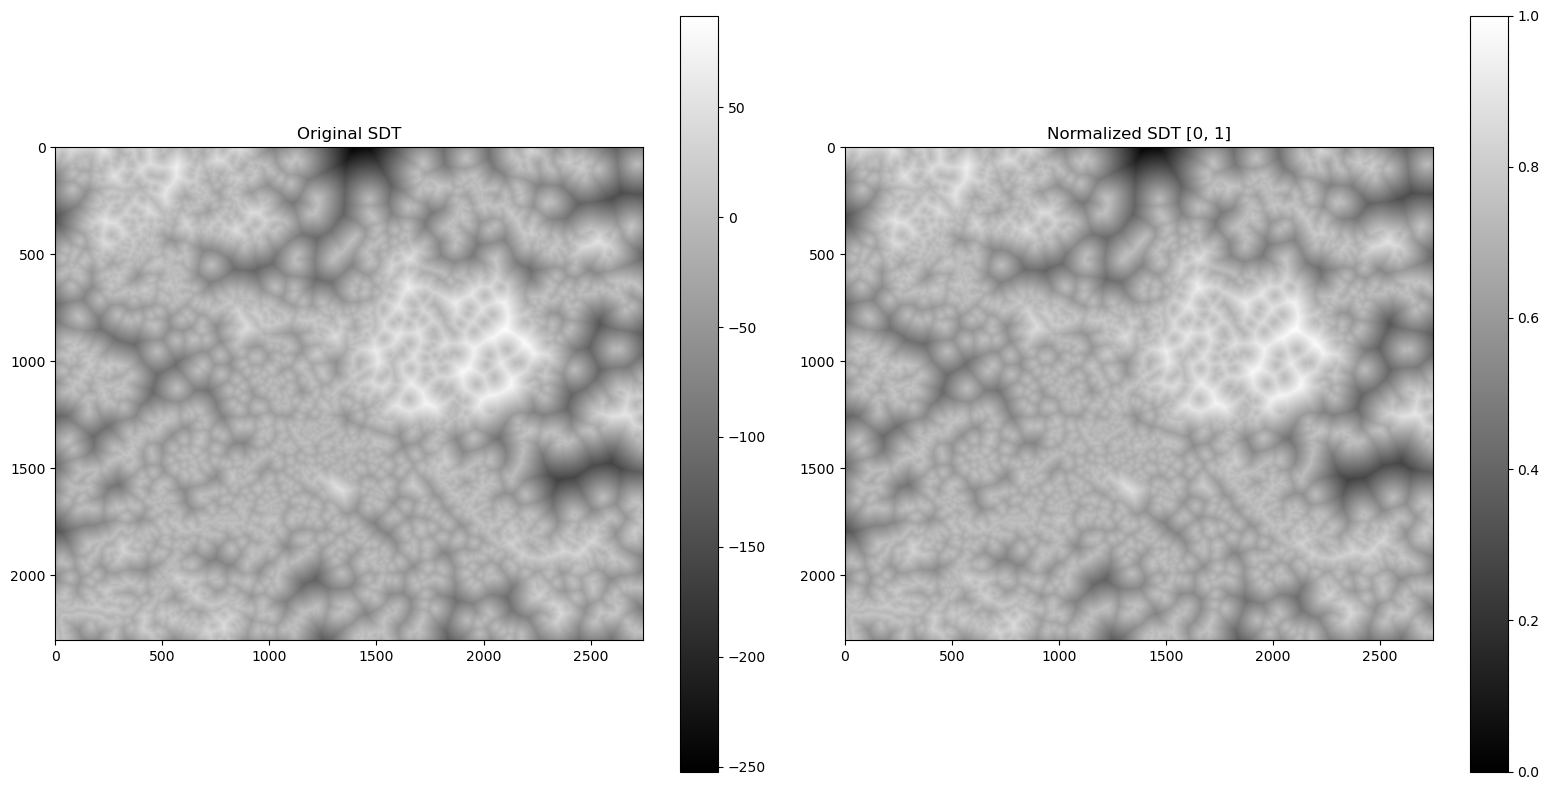

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Original SDT
im1 = ax1.imshow(sdt_pugs.squeeze(), cmap="gray")
ax1.set_title("Original SDT")
plt.colorbar(im1, ax=ax1)

# Normalized SDT
im2 = ax2.imshow(normalized_sdt_pugs.squeeze(), cmap="gray")
ax2.set_title("Normalized SDT [0, 1]")
plt.colorbar(im2, ax=ax2)

plt.tight_layout()
plt.show()

In [25]:
normalized_sdt_pugs

<xarray.DataArray (band: 1, y: 2301, x: 2747)> Size: 51MB
array([[[0.87398077, 0.87219801, 0.87045369, ..., 0.4950907 ,
         0.49418731, 0.49325208],
        [0.87171059, 0.86989822, 0.86812417, ..., 0.49785761,
         0.49694363, 0.49599754],
        [0.86946463, 0.86762198, 0.86581747, ..., 0.50062109,
         0.49969629, 0.4987391 ],
        ...,
        [0.79427731, 0.79137   , 0.78846269, ..., 0.66635578,
         0.66635578, 0.66635578],
        [0.79427731, 0.79137   , 0.78846269, ..., 0.66344847,
         0.66344847, 0.66344847],
        [0.79427731, 0.79137   , 0.78846269, ..., 0.66054116,
         0.66054116, 0.66054116]]])
Coordinates:
  * x            (x) float64 22kB 4.003e+05 4.003e+05 ... 4.277e+05 4.277e+05
  * y            (y) float64 18kB 5.671e+06 5.671e+06 ... 5.648e+06 5.648e+06
    spatial_ref  int64 8B 0
  * band         (band) int64 8B 15
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

# Calculate NDVI

In [26]:
# red = data_new_norm_xarray.sel(band=4)
# nir = data_new_norm_xarray.sel(band=8)

# # Calculate NDVI
# ndvi = (nir - red) / (nir + red)
# ndvi = ndvi.expand_dims('band').assign_coords(band=[16])

# print("NDVI min:", ndvi.min().values, "NDVI max:", ndvi.max().values)

# # Plot the NDVI
# plt.figure(figsize=(10, 10))
# plt.imshow(ndvi.sel(band=16), cmap='RdYlGn')
# plt.colorbar(label='NDVI')
# plt.title('NDVI')
# plt.show()

NDVI min: -0.3626763 NDVI max: 1.0


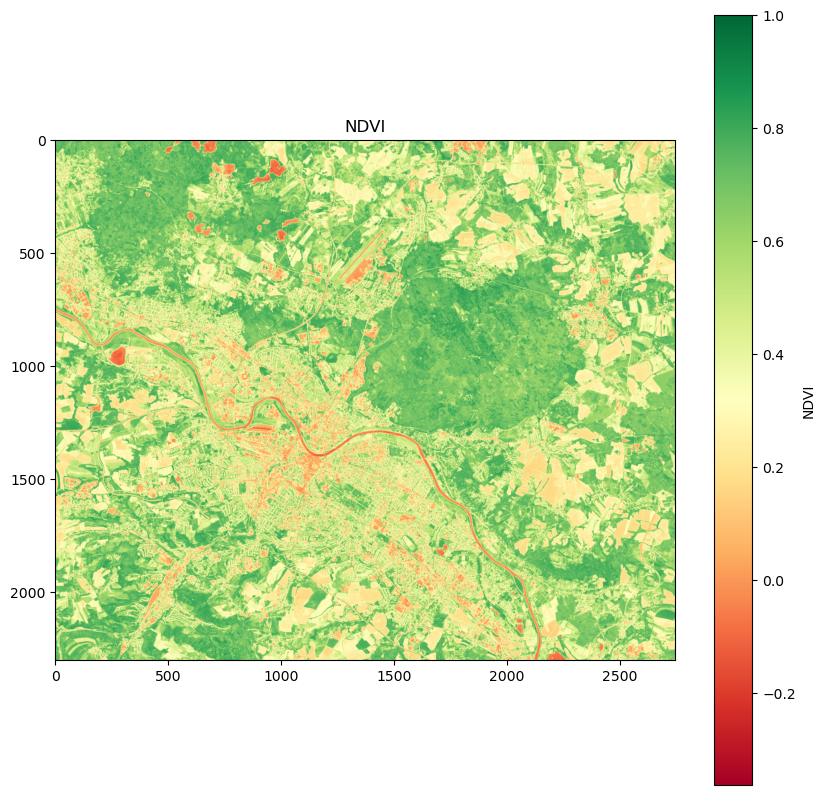

In [27]:
red = processed_sat_img.sel(band=4)
nir = processed_sat_img.sel(band=8)

# Calculate NDVI
ndvi = (nir - red) / (nir + red)
# Interpolate NaN values
# ndvi = ndvi.fillna(0)
ndvi = ndvi.interpolate_na(dim="x")
ndvi = ndvi.expand_dims("band").assign_coords(band=[16])

print("NDVI min:", ndvi.min().values, "NDVI max:", ndvi.max().values)

# Plot the NDVI
plt.figure(figsize=(10, 10))
plt.imshow(ndvi.sel(band=16), cmap="RdYlGn")
plt.colorbar(label="NDVI")
plt.title("NDVI")
plt.show()

In [28]:
# # Apply to NDVI (band 16)
# normalized_ndvi = min_max_normalize(ndvi)

# # Plot the NDVI
# plt.figure(figsize=(10, 10))
# plt.imshow(normalized_ndvi.sel(band=16), cmap='RdYlGn')
# plt.colorbar(label='NDVI')
# plt.title('NDVI')
# plt.show()

# Calculate NDWI

NDWI min: -1.0 NDVI max: 0.6039984


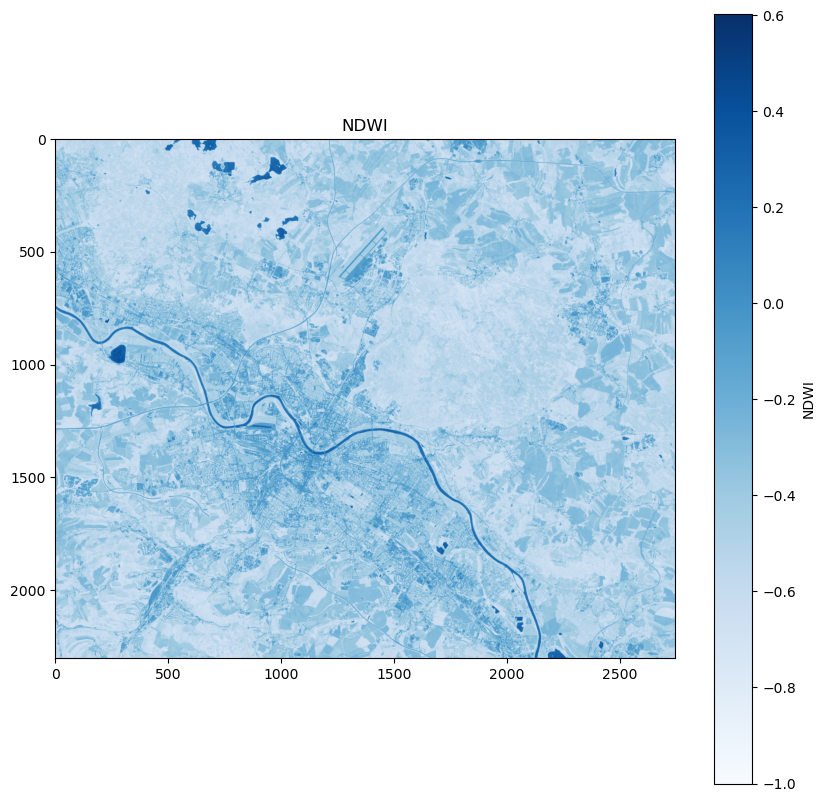

In [29]:
green = processed_sat_img.sel(band=3)

# Calculate NDWI
ndwi = (green - nir) / (green + nir)
# ndwi = ndwi.fillna(0)
ndwi = ndwi.interpolate_na(dim="x")
ndwi = ndwi.expand_dims("band").assign_coords(band=[17])

print("NDWI min:", ndwi.min().values, "NDVI max:", ndwi.max().values)

# Plot the NDWI
plt.figure(figsize=(10, 10))
plt.imshow(ndwi.sel(band=17), cmap="Blues")
plt.colorbar(label="NDWI")
plt.title("NDWI")
plt.show()

# Calculate NDBI

In [30]:
# swir = processed_sat_img.sel(band=12)

# # Calculate NDBI
# ndbi = (swir - nir) / (swir + nir)
# # ndbi = ndbi.fillna(0)
# ndbi = ndbi.interpolate_na(dim='x')
# ndbi = ndbi.expand_dims('band').assign_coords(band=[18])

# print("NDBI min:", ndbi.min().values, "NDBI max:", ndbi.max().values)

# # Plot the NDBI
# plt.figure(figsize=(10, 10))
# plt.imshow(ndbi.sel(band=18), cmap='Reds')
# plt.colorbar(label='NDBI')
# plt.title('NDBI')
# plt.show()

# Stack Sentinel-2 image and indices in one file

In [31]:
# stacked_img = xr.concat([processed_sat_img, binary_mask_pugs, normalized_sdt_pugs, ndvi, ndwi, ndbi], dim='band')
# stacked_img = xr.concat([processed_sat_img, binary_mask_pugs, normalized_sdt_pugs, ndvi, ndwi], dim='band')
stacked_img = xr.concat(
    [processed_sat_img, binary_mask_pugs, normalized_sdt_pugs, ndvi, ndwi], dim="band"
)

In [32]:
# Check for NaNs in input bands
for i in range(stacked_img.shape[0]):
    print(f"Min value {i + 1}: {stacked_img.sel(band=i + 1).min().values}")
    print(f"Max value {i + 1}: {stacked_img.sel(band=i + 1).max().values}")
    print(f"NaN values {i + 1}: {np.isnan(stacked_img.sel(band=i + 1)).sum().values}")
    print()

Min value 1: 0.09969999641180038
Max value 1: 0.4296000003814697
NaN values 1: 0

Min value 2: 0.05810000002384186
Max value 2: 1.0
NaN values 2: 0

Min value 3: 0.0
Max value 3: 1.0
NaN values 3: 0

Min value 4: 0.0
Max value 4: 1.0
NaN values 4: 0

Min value 5: 0.0
Max value 5: 1.0
NaN values 5: 0

Min value 6: 0.022099999710917473
Max value 6: 1.0
NaN values 6: 0

Min value 7: 0.024700000882148743
Max value 7: 1.0
NaN values 7: 0

Min value 8: 0.024399999529123306
Max value 8: 1.0
NaN values 8: 0

Min value 9: 0.02019999921321869
Max value 9: 1.0
NaN values 9: 0

Min value 10: 0.006200000178068876
Max value 10: 0.17339999973773956
NaN values 10: 0

Min value 11: 0.0006000000284984708
Max value 11: 0.002300000051036477
NaN values 11: 0

Min value 12: 0.009200000204145908
Max value 12: 1.0
NaN values 12: 0

Min value 13: 0.00419999985024333
Max value 13: 1.0
NaN values 13: 0

Min value 14: 0.0
Max value 14: 1.0
NaN values 14: 0

Min value 15: 0.0
Max value 15: 1.0
NaN values 15: 0

Mi

# Clipped image to dresden boundary

In [ ]:
boundary_gdf = gpd.read_file("../data/raw/boundary/dresden_boundary.geojson")

if boundary_gdf.crs != stacked_img.rio.crs:
    boundary_gdf = boundary_gdf.to_crs(stacked_img.rio.crs)

clipped_image = stacked_img.rio.clip(boundary_gdf.geometry.values, boundary_gdf.crs)

In [34]:
# Check for NaNs in input bands
for i in range(clipped_image.shape[0]):
    print(f"Min value {i + 1}: {clipped_image.sel(band=i + 1).min().values}")
    print(f"Max value {i + 1}: {clipped_image.sel(band=i + 1).max().values}")
    print(f"NaN values {i + 1}: {np.isnan(clipped_image.sel(band=i + 1)).sum().values}")
    print()

Min value 1: 0.09969999641180038
Max value 1: 0.4296000003814697
NaN values 1: 2855105

Min value 2: 0.05810000002384186
Max value 2: 1.0
NaN values 2: 2855105

Min value 3: 0.0
Max value 3: 1.0
NaN values 3: 2855105

Min value 4: 0.0
Max value 4: 1.0
NaN values 4: 2855105

Min value 5: 0.0
Max value 5: 1.0
NaN values 5: 2855105

Min value 6: 0.022099999710917473
Max value 6: 1.0
NaN values 6: 2855105

Min value 7: 0.024700000882148743
Max value 7: 1.0
NaN values 7: 2855105

Min value 8: 0.024399999529123306
Max value 8: 1.0
NaN values 8: 2855105

Min value 9: 0.02019999921321869
Max value 9: 1.0
NaN values 9: 2855105

Min value 10: 0.006800000090152025
Max value 10: 0.1445000022649765
NaN values 10: 2855105

Min value 11: 0.0006000000284984708
Max value 11: 0.002300000051036477
NaN values 11: 2855105

Min value 12: 0.009399999864399433
Max value 12: 1.0
NaN values 12: 2855105

Min value 13: 0.00559999980032444
Max value 13: 1.0
NaN values 13: 2855105

Min value 14: 0.0
Max value 14: 1

# Save file

## Save clipped image

In [45]:
output_path = "../data/processed/sentinel-2/stacked_sentinel2_dresden_clipped.geotiff"

In [46]:
try:
    os.makedirs("../data/processed/sentinel-2")
except FileExistsError:
    # Directory already exists
    pass

# Prepare data
array_data = clipped_image.values
height, width = array_data.shape[1], array_data.shape[2]
bands = array_data.shape[0]
transform = clipped_image.rio.transform()
crs = clipped_image.rio.crs

with rasterio.open(
    output_path,
    "w",
    driver="GTiff",
    height=height,
    width=width,
    count=bands,
    dtype="float32",  # Force float32
    crs=crs,
    transform=transform,
    nodata=-9999,
) as dst:
    # Write each band with explicit float handling
    for i in range(bands):
        # Ensure this band is float32
        band_data = array_data[i].astype("float32")
        dst.write(band_data, i + 1)

## Save regular image (no clipping)

In [47]:
output_path = "../data/processed/sentinel-2/stacked_sentinel2_dresden.geotiff"

In [ ]:
# # Save image without clipping

# try:
#    os.makedirs("../data/processed/sentinel-2")
# except FileExistsError:
#    # Directory already exists
#    pass

# # Convert to numpy array
# data_array = stacked_img.values
# height, width = data_array.shape[1], data_array.shape[2]
# bands = data_array.shape[0]

# # Get geotransform and projection from xarray
# transform = processed_sat_img.rio.transform()
# crs = processed_sat_img.rio.crs

# # Create GDAL driver
# driver = gdal.GetDriverByName('GTiff')
# ds = driver.Create(output_path, width, height, bands, gdal.GDT_Float32)

# # Set projection and transformation
# ds.SetProjection(crs.to_wkt())
# ds.SetGeoTransform(transform.to_gdal())

# # Write each band
# for i in range(bands):
#     band = ds.GetRasterBand(i+1)
#     band.WriteArray(data_array[i])
#     band.FlushCache()

# # Close dataset
# ds = None

/root/miniforge3/envs/pugs-detection-new/lib/python3.12/site-packages/osgeo/gdal.py:311: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


# Open the saved file

In [38]:
# file_path = '../data/processed/sentinel-2/stacked_sentinel2_dresden.geotiff'
file_path = "../data/processed/sentinel-2/stacked_sentinel2_dresden_clipped.geotiff"
data = rioxarray.open_rasterio(file_path, masked=True)

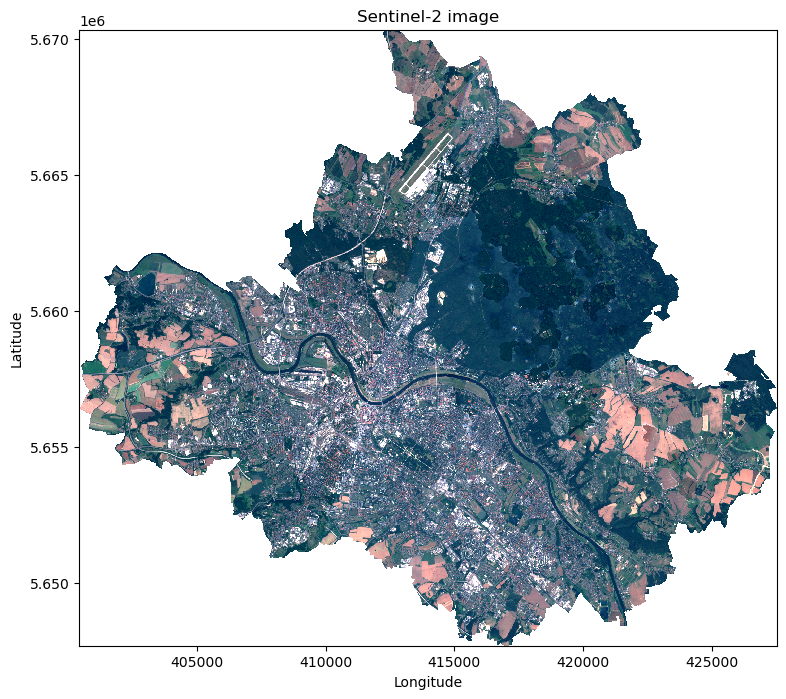

In [39]:
# Plot the raster data
plt.figure(figsize=(9, 8))
data.sel(band=[4, 3, 2]).plot.imshow(robust=True)
plt.title("Sentinel-2 image")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

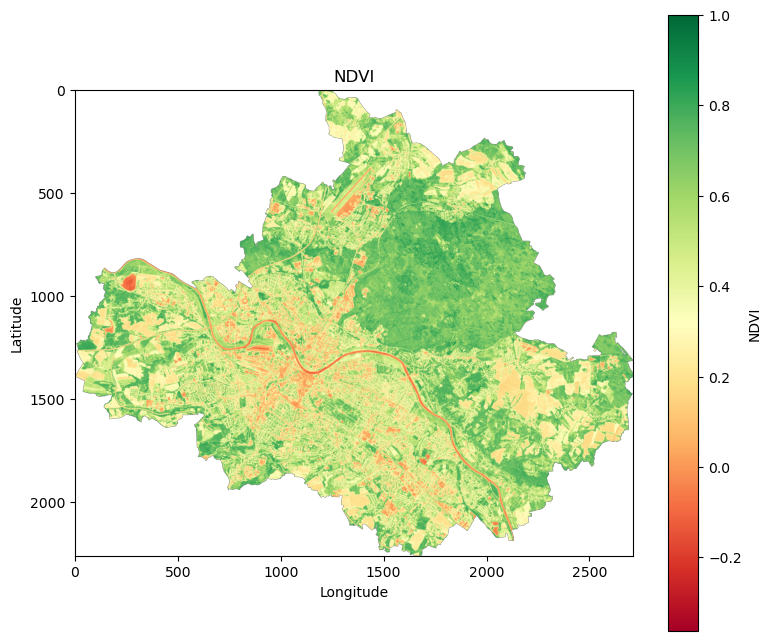

In [40]:
# Plot the raster data
plt.figure(figsize=(9, 8))
plt.imshow(data.sel(band=16), cmap="RdYlGn")
plt.title("NDVI")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.colorbar(label="NDVI")
plt.show()

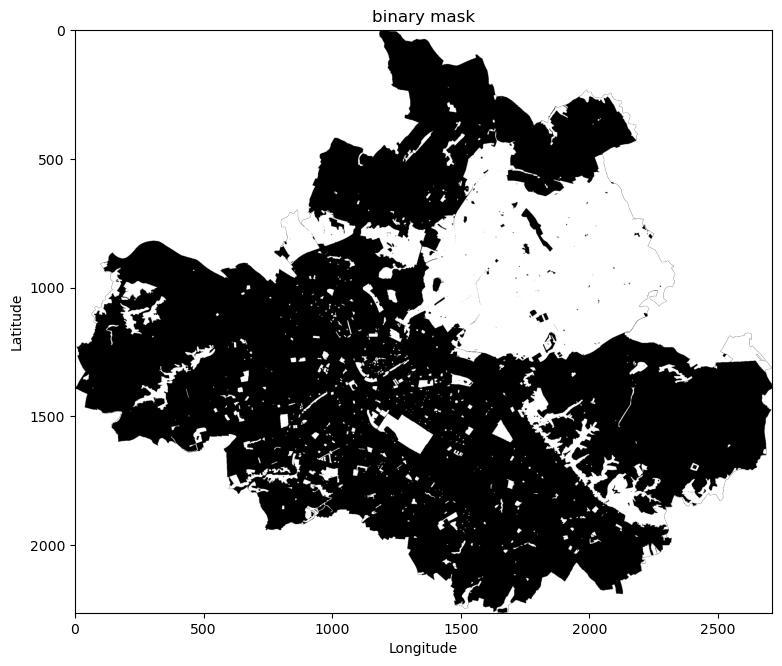

In [41]:
# Plot the raster data
plt.figure(figsize=(9, 8))
plt.imshow(data.sel(band=14), cmap="gray")
plt.title("binary mask")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [42]:
data.sel(band=15)

<xarray.DataArray (y: 2264, x: 2711)> Size: 25MB
[6137704 values with dtype=float32]
Coordinates:
    band         int64 8B 15
  * x            (x) float64 22kB 4.004e+05 4.004e+05 ... 4.275e+05 4.275e+05
  * y            (y) float64 18kB 5.67e+06 5.67e+06 ... 5.648e+06 5.648e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

SDT min: 0.117629394 , SDT max: 1.0


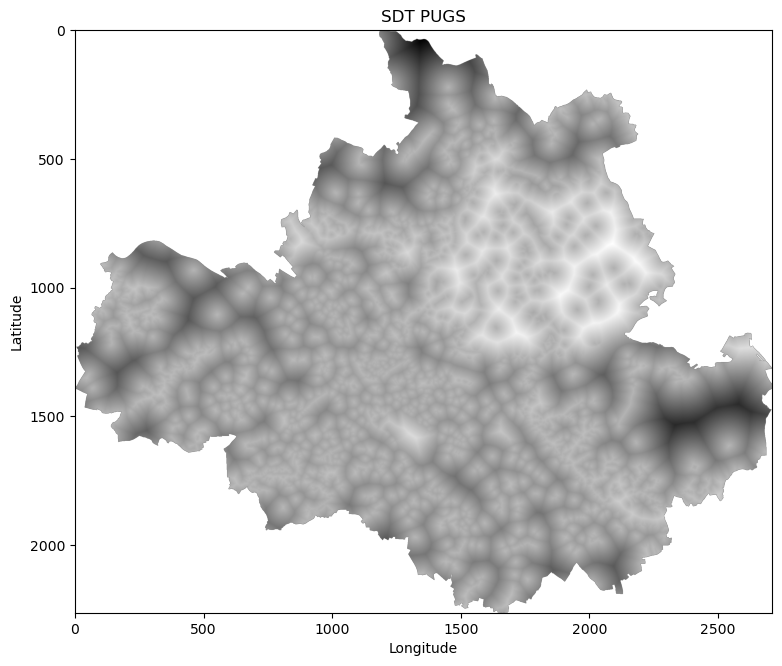

In [43]:
print(
    "SDT min:",
    data.sel(band=15).min().values,
    ", SDT max:",
    data.sel(band=15).max().values,
)
# Plot the raster data
plt.figure(figsize=(9, 8))
plt.imshow(data.sel(band=15), cmap="gray")
plt.title("SDT PUGS")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()